In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import pickle

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Convert text data to numerical features
y = data[target_column]  # Target labels

# Step 2: Split the dataset into training and testing sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the SVM model
print("Training SVM Model (Linear Kernel)...")
svm_model = SVC(kernel='linear')  # SVM with a linear kernel
svm_model.fit(X_train_tfidf, y_train)

# Step 4: Save the trained SVM model
model_path = r"C:\Users\PC\Downloads\SVM_model.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(svm_model, f)
print(f"Trained SVM model saved to {model_path}")

# Step 5: Evaluate the SVM model
y_pred_svm = svm_model.predict(X_test_tfidf)

# Print accuracy and classification report
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))


Training SVM Model (Linear Kernel)...
Trained SVM model saved to C:\Users\PC\Downloads\SVM_model.pkl
SVM Accuracy: 93.42%
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     23238
           1       0.94      0.93      0.93     23171

    accuracy                           0.93     46409
   macro avg       0.93      0.93      0.93     46409
weighted avg       0.93      0.93      0.93     46409



In [5]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


Confusion Matrix:
[[21864  1374]
 [ 1681 21490]]


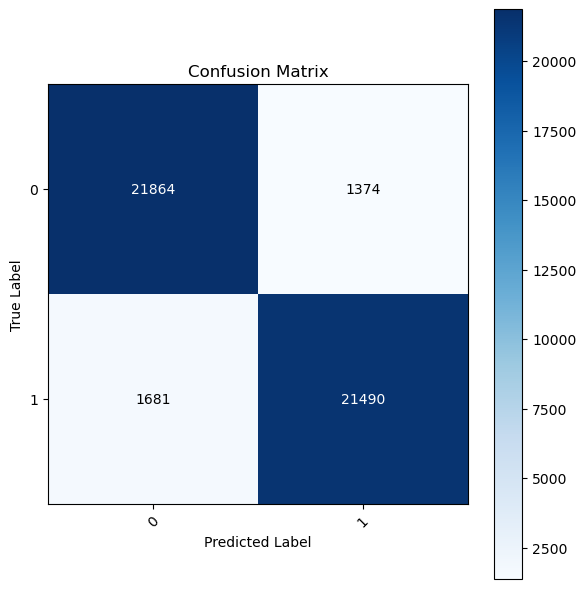

In [6]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Display confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = np.unique(y_test)  # Unique classes
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add labels to cells
thresh = cm.max() / 2.0
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()


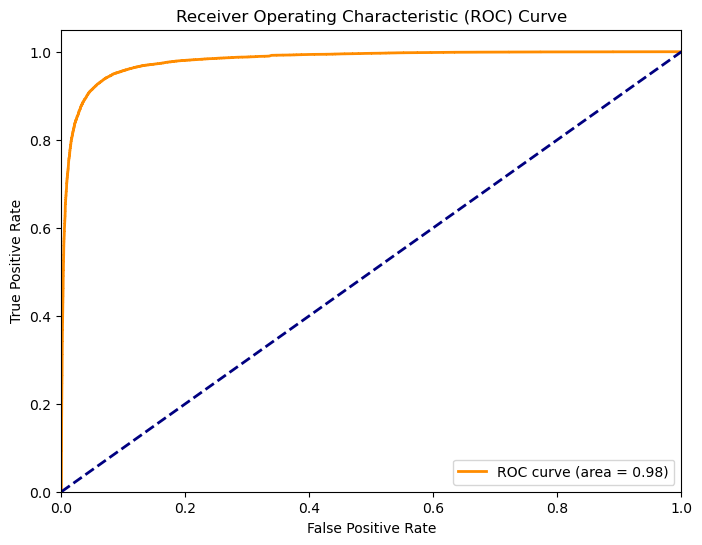

In [7]:
# Ensure your labels are binary (e.g., 0 or 1)
if len(np.unique(y)) == 2:
    # Get decision function or probabilities
    y_score = svm_model.decision_function(X_test_tfidf)
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
else:
    print("ROC curve is only available for binary classification.")


SVM MAE: 0.0658, MSE: 0.0658, RMSE: 0.2566


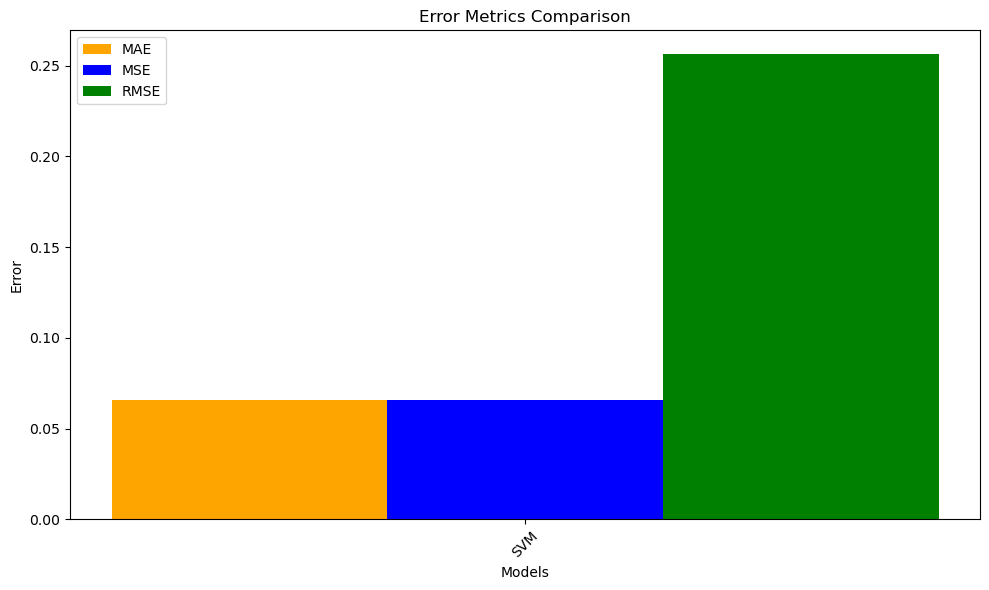

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store error metrics
error_metrics = {}

# For the SVM model (assuming it's already trained and available)
model_name = "SVM"  # You can change this if you have multiple models

# Predict on the test set
y_pred = svm_model.predict(X_test_tfidf)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Store error metrics
error_metrics[model_name] = {"MAE": mae, "MSE": mse, "RMSE": rmse}

# Print metrics
print(f"{model_name} MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
